In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


# Wandb Connnection

In [2]:
!pip install -q wandb transformers sentencepiece

from kaggle_secrets import UserSecretsClient
import wandb

user_secrets = UserSecretsClient()
wandb_api = user_secrets.get_secret("WANDB_API_KEY")
wandb.login(key=wandb_api)

PROJECT = "DL-24f1000881-notebook-t22026"
ENTITY = "24f1000881-indian-institute-of-technology-madras"

def start_run(run_name, config_dict):
    run = wandb.init(
        project=PROJECT,
        entity=ENTITY,
        name=run_name,
        config=config_dict,
        reinit=True
    )
    return run

print("W&B login successful")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


W&B login successful


# Import Libraries

In [3]:
import os
import re
import gc
import math
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, log_loss, classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

import lightgbm as lgbm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModelForMultipleChoice,
    get_linear_schedule_with_warmup
)

from tqdm.auto import tqdm

# Configuration

In [4]:
SEED = 42
OPTION_LABELS = ["A", "B", "C", "D", "E"]
LABEL2ID = {"A":0, "B":1, "C":2, "D":3, "E":4}
ID2LABEL = {v:k for k, v in LABEL2ID.items()}

MAX_LEN_SCRATCH = 128
MAX_LEN_TRANSFORMER = 256

BATCH_SIZE_SCRATCH = 64
BATCH_SIZE_TRANSFORMER = 8

SCRATCH_EPOCHS = 5
TRANSFORMER_EPOCHS = 2

SCRATCH_LR = 2e-3
TRANSFORMER_LR = 2e-5

TFIDF_MAX_FEATURES = 30000
MC_MODEL_NAME = "distilbert-base-uncased"

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Main device:", device)

pd.set_option("display.max_colwidth", 300)
sns.set_style("whitegrid")

Main device: cuda


In [5]:
# Loading Data


train_path = "/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv"
test_path = "/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv"
sample_path = "/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
sample_df = pd.read_csv(sample_path)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Sample submission shape:", sample_df.shape)

display(train_df.head(2))
display(test_df.head(2))
display(sample_df.head(2))

Train shape: (2000, 8)
Test shape: (500, 7)
Sample submission shape: (500, 2)


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.,"Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. The relationship to the past involves acknowledging it as a historical era, and the relationship to the future involves creating a world that will endure beyond one'...","Martin Heidegger believes that humans do not exist inside time, but that they are time. The relationship to the past is a present awareness of having been, and the relationship to the future involves anticipating a potential possibility, task, or engagement.","Martin Heidegger does not believe in the existence of time or that it has any effect on human consciousness. The relationship to the past and the future is insignificant, and human existence is solely based on the present.",Martin Heidegger believes that the relationship between time and human existence is cyclical. The past and present are interconnected and the future is predetermined. Human beings do not have free will.,"Martin Heidegger believes that time is an illusion, and the past, present, and future are all happening simultaneously. Humans exist outside of this illusion and are guided by a higher power.",B
1,2,What is accelerator-based light-ion fusion?,"Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-ion fusion reactions. This method is relatively easy to implement and can be done in an efficient manner, requiring only a vacuum tube, a pair of elec...","Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce heavy-ion fusion reactions. This method is relatively difficult to implement and requires a complex system of vacuum tubes, electrodes, and transformers. Fu...","Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-ion fusion reactions. This method is relatively difficult to implement and requires a complex system of vacuum tubes, electrodes, and transformers. Fu...","Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce heavy-ion fusion reactions. This method is relatively easy to implement and can be done in an efficient manner, requiring only a vacuum tube, a pair of elec...","Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-ion fission reactions. This method is relatively easy to implement and can be done in an efficient manner, requiring only a vacuum tube, a pair of ele...",A


,id,prompt,A,B,C,D,E
0,1,Pick the best possible answer: What is the relationship between the Hamiltonians and eigenstates in supersymmetric quantum mechanics? carefully.,"For every eigenstate of one Hamiltonian, its partner Hamiltonian has a corresponding eigenstate with the same energy.","For every eigenstate of one Hamiltonian, its partner Hamiltonian has a corresponding eigenstate with a higher energy.","For every eigenstate of one Hamiltonian, its partner Hamiltonian has a corresponding eigenstate with a different spin.","For every eigenstate of one Hamiltonian, its partner Hamiltonian has a corresponding eigenstate with a different energy.","For every eigenstate of one Hamiltonian, its partner Hamiltonian has a corresponding eigenstate with a lower energy."
1,2,"What is the estimated redshift of CEERS-93316, a candidate high-redshift galaxy observed by the James Webb Space Telescope?","Approximately z = 6.0, corresponding to 1 billion years after the Big Bang.","Approximately z = 16.7, corresponding to 235.8 million years after the Big Bang.","Approximately z = 3.0, corresponding to 5 billion years after the Big Bang.","Approximately z = 10.0, corresponding to 13 billion years after the Big Bang.","Approximately z = 13.0, corresponding to 30 billion light-years away from Earth."


,ID,Prediction
0,1,A B C
1,2,A B C


# Basic Checks

In [6]:
print("Train columns:", train_df.columns.tolist())
print("Test columns :", test_df.columns.tolist())

print("\nMissing values in train:")
display(train_df.isnull().sum())

print("\nMissing values in test:")
display(test_df.isnull().sum())

Train columns: ['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer']
Test columns : ['id', 'prompt', 'A', 'B', 'C', 'D', 'E']

Missing values in train:


id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64


Missing values in test:


id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
dtype: int64

### Answer Distribution

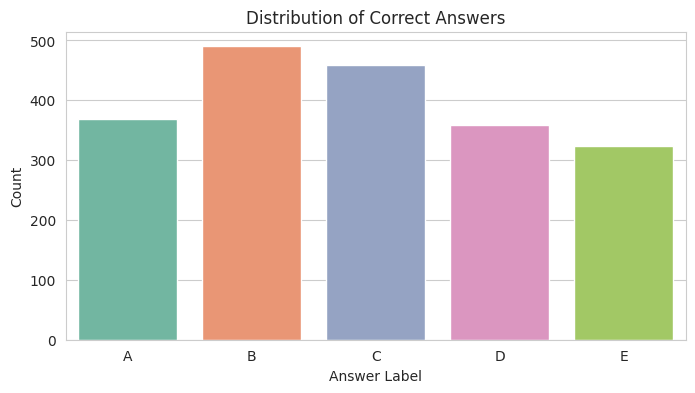

answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64

In [7]:
plt.figure(figsize=(8, 4))
sns.countplot(x=train_df["answer"], order=["A", "B", "C", "D", "E"], palette="Set2")
plt.title("Distribution of Correct Answers")
plt.xlabel("Answer Label")
plt.ylabel("Count")
plt.show()

display(train_df["answer"].value_counts())

### Prompt and Option length Analysis

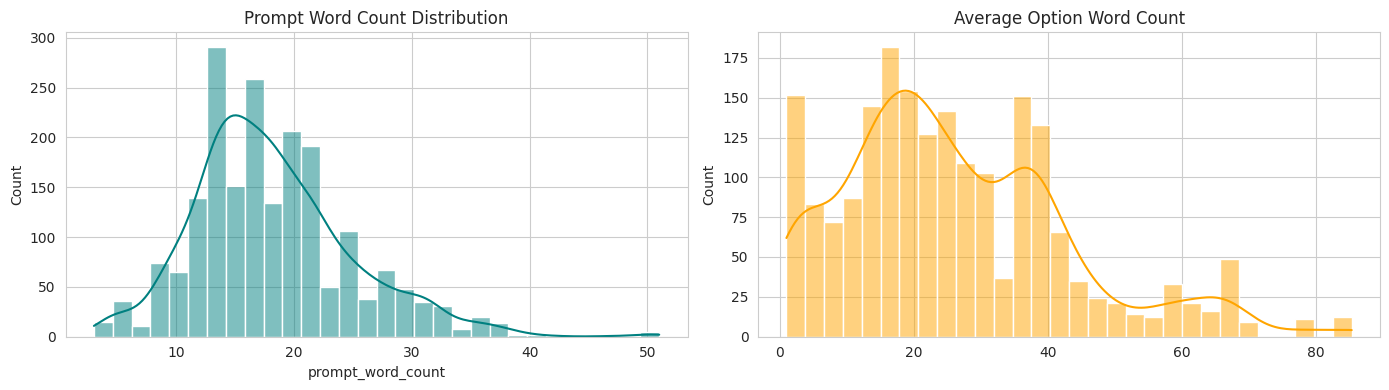

In [8]:

train_df["prompt_word_count"] = train_df["prompt"].astype(str).apply(lambda x: len(x.split()))

for col in ["A", "B", "C", "D", "E"]:
    train_df[f"{col}_word_count"] = train_df[col].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(train_df["prompt_word_count"], bins=30, kde=True, color="teal", ax=axes[0])
axes[0].set_title("Prompt Word Count Distribution")

avg_option_word_count = train_df[[f"{c}_word_count" for c in ["A", "B", "C", "D", "E"]]].mean(axis=1)
sns.histplot(avg_option_word_count, bins=30, kde=True, color="orange", ax=axes[1])
axes[1].set_title("Average Option Word Count")

plt.tight_layout()
plt.show()

In [9]:
# Sample Questions

sample_rows = train_df.sample(2, random_state=SEED)

for _, row in sample_rows.iterrows():
    print("=" * 100)
    print("ID:", row["id"])
    print("PROMPT:", row["prompt"])
    print("A:", row["A"])
    print("B:", row["B"])
    print("C:", row["C"])
    print("D:", row["D"])
    print("E:", row["E"])
    print("CORRECT ANSWER:", row["answer"])

ID: 1861
PROMPT: Select the most accurate option: What is the propagation constant in sinusoidal waves? carefully.
A: The propagation constant is a measure of the amplitude of the sinusoidal wave that varies with distance.
B: The propagation constant is a real number that remains constant with distance due to the phase change in the sinusoidal wave.
C: The propagation constant is a real number that varies with distance due to the phase change in the sinusoidal wave.
D: The propagation constant is a complex number that varies with distance due to the phase change in the sinusoidal wave.
E: The propagation constant is a complex number that remains constant with distance due to the phase change in the sinusoidal wave.
CORRECT ANSWER: D
ID: 354
PROMPT: Pick the best possible answer: What is the most popular explanation for the shower-curtain effect? among the listed options.
A: The pressure differential between the inside and outside of the shower
B: The reduce in velocity resulting in an 

### Text Cleaning

In [10]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s\-\?\!\.,:;]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

for df in [train_df, test_df]:
    df['prompt_clean'] = df['prompt'].apply(clean_text)
    for col in OPTION_LABELS:
        df[f'{col}_clean'] = df[col].apply(clean_text)

In [11]:
# Train-Validation Split

unique_ids = train_df["id"].unique()
train_ids, val_ids = train_test_split(unique_ids, test_size=0.2, random_state=SEED)

train_main = train_df[train_df["id"].isin(train_ids)].reset_index(drop=True)
val_main = train_df[train_df["id"].isin(val_ids)].reset_index(drop=True)

print("Train questions:", train_main.shape)
print("Validation questions:", val_main.shape)

Train questions: (1600, 20)
Validation questions: (400, 20)


# Augmentation

In [12]:
label2id = {"A": 0, "B": 1, "C": 2, "D": 3, "E": 4}
id2label = {v: k for k, v in label2id.items()}

def apk(actual, predicted, k=3):
    predicted = predicted[:k]
    for i, p in enumerate(predicted):
        if p == actual:
            return 1.0 / (i + 1)
    return 0.0

def mapk(actuals, predictions, k=3):
    return np.mean([apk(a, p, k) for a, p in zip(actuals, predictions)])

def make_top3_predictions(df, score_col):
    ranked = (
        df.sort_values(["id", score_col], ascending=[True, False])
          .groupby("id")["option_label"]
          .apply(list)
          .reset_index()
    )
    ranked["top3"] = ranked["option_label"].apply(lambda x: x[:3])
    return ranked[["id", "top3"]]

def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "loss": log_loss(y_true, y_prob, labels=[0, 1])
    }

def softmax_numpy(x):
    x = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

def compute_multiclass_metrics(y_true, logits):
    probs = softmax_numpy(logits)
    y_pred = np.argmax(probs, axis=1)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "loss": log_loss(y_true, probs, labels=[0, 1, 2, 3, 4])
    }
    return metrics, y_pred, probs

In [13]:
# Leakage-safe retrieval

retrieval_tfidf = TfidfVectorizer(max_features=15000, stop_words="english")

train_prompt_vectors = retrieval_tfidf.fit_transform(train_main["prompt"])
val_prompt_vectors = retrieval_tfidf.transform(val_main["prompt"])
test_prompt_vectors = retrieval_tfidf.transform(test_df["prompt"])

def get_retrieved_context(query_vector, reference_df, reference_vectors, top_k=1, exclude_index=None):
    sims = cosine_similarity(query_vector, reference_vectors).flatten()

    if exclude_index is not None:
        sims[exclude_index] = -1

    top_idx = np.argsort(-sims)[:top_k]

    retrieved_texts = []
    for idx in top_idx:
        retrieved_prompt = reference_df.iloc[idx]["prompt"]
        retrieved_answer = reference_df.iloc[idx]["answer"]
        retrieved_texts.append(
            f"similar_question: {retrieved_prompt} similar_answer: {retrieved_answer}"
        )

    return " ".join(retrieved_texts)

train_main = train_main.copy()
val_main = val_main.copy()
test_df = test_df.copy()

train_main["retrieved_context"] = [
    get_retrieved_context(train_prompt_vectors[i], train_main, train_prompt_vectors, top_k=1, exclude_index=i)
    for i in range(train_prompt_vectors.shape[0])
]

val_main["retrieved_context"] = [
    get_retrieved_context(val_prompt_vectors[i], train_main, train_prompt_vectors, top_k=1, exclude_index=None)
    for i in range(val_prompt_vectors.shape[0])
]

test_df["retrieved_context"] = [
    get_retrieved_context(test_prompt_vectors[i], train_main, train_prompt_vectors, top_k=1, exclude_index=None)
    for i in range(test_prompt_vectors.shape[0])
]

display(train_main[["prompt", "retrieved_context"]].head(3))

,prompt,retrieved_context
0,Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.,similar_question: Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options. similar_answer: B
1,What is accelerator-based light-ion fusion?,similar_question: Determine the correct option: What is accelerator-based light-ion fusion? similar_answer: A
2,Determine the correct option: What is the term used in astrophysics to describe light-matter interactions resulting in energy shifts in the radiation field? among the listed options.,similar_question: Determine the correct option: What is the term used in astrophysics to describe light-matter interactions resulting in energy shifts in the radiation field? carefully. similar_answer: C


In [14]:
# Build long format for ranking models

def build_long_format(df, is_train=True):
    rows = []
    labels = ["A", "B", "C", "D", "E"]

    for _, row in df.iterrows():
        for label in labels:
            combined_text = (
                f"question: {row['prompt']} "
                f"context: {row['retrieved_context']} "
                f"[SEP] option: {row[label]}"
            )

            item = {
                "id": row["id"],
                "prompt": row["prompt"],
                "option_label": label,
                "option_text": row[label],
                "retrieved_context": row["retrieved_context"],
                "combined_text": combined_text
            }

            if is_train:
                item["target"] = 1 if row["answer"] == label else 0

            rows.append(item)

    return pd.DataFrame(rows)

train_long = build_long_format(train_main, is_train=True)
val_long = build_long_format(val_main, is_train=True)
test_long = build_long_format(test_df, is_train=False)

print("Train long shape:", train_long.shape)
print("Validation long shape:", val_long.shape)
print("Test long shape:", test_long.shape)

Train long shape: (8000, 7)
Validation long shape: (2000, 7)
Test long shape: (2500, 6)


# MAP@3 Helpers

In [15]:
def apk(actual, predicted, k=3):
    predicted = predicted[:k]
    for i, p in enumerate(predicted):
        if p == actual:
            return 1.0 / (i + 1)
    return 0.0

def mapk(actuals, predictions, k=3):
    return np.mean([apk(a, p, k) for a, p in zip(actuals, predictions)])

def make_top3_predictions(df, score_col):
    ranked = (
        df.sort_values(["id", score_col], ascending=[True, False])
          .groupby("id")["option_label"]
          .apply(list)
          .reset_index()
    )
    ranked["top3"] = ranked["option_label"].apply(lambda x: x[:3])
    return ranked[["id", "top3"]]

# Building long format for Model 1

In [16]:
def build_long_format(df, is_train=True):
    rows = []
    for _, row in df.iterrows():
        for label in OPTION_LABELS:
            text = f"question: {row['prompt_clean']} [SEP] option: {row[f'{label}_clean']}"
            item = {
                'id': row['id'],
                'option_label': label,
                'combined_text': text,
            }
            if is_train:
                item['target'] = 1 if row['answer'] == label else 0
            rows.append(item)
    return pd.DataFrame(rows)

train_long = build_long_format(train_main, is_train=True)
val_long = build_long_format(val_main, is_train=True)
test_long = build_long_format(test_df, is_train=False)

print("Train long shape:", train_long.shape)
print("Validation long shape:", val_long.shape)
print("Test long shape:", test_long.shape)

Train long shape: (8000, 4)
Validation long shape: (2000, 4)
Test long shape: (2500, 3)


# Model 1 - TF-IDF + Lightgbm


In [17]:
lgbm_run = start_run(
    "model1_tfidf_lgbm",
    {
        "model_type": "your_choice",
        "model_name": "TF-IDF + LightGBM",
        "max_features": 30000,
        "ngram_range": "1-2"
    }
)

tfidf = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    ngram_range=(1, 2),
    stop_words='english'
)

X_train_lgbm = tfidf.fit_transform(train_long['combined_text'])
X_val_lgbm = tfidf.transform(val_long['combined_text'])

y_train_lgbm = train_long['target'].values
y_val_lgbm = val_long['target'].values

lgbm_model = lgbm.LGBMClassifier(
    objective='binary',
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=SEED
)

lgbm_model.fit(X_train_lgbm, y_train_lgbm)
val_long['score_lgbm'] = lgbm_model.predict_proba(X_val_lgbm)[:, 1]

val_top3_lgbm = make_top3_predictions(val_long, 'score_lgbm')
val_eval_lgbm = val_top3_lgbm.merge(val_main[['id', 'answer']], on='id', how='left')

lgbm_map3 = mapk(val_eval_lgbm['answer'].tolist(), val_eval_lgbm['top3'].tolist(), k=3)
lgbm_loss = log_loss(y_val_lgbm, val_long['score_lgbm'].values)
lgbm_acc = accuracy_score(y_val_lgbm, (val_long['score_lgbm'].values > 0.5).astype(int))
lgbm_f1 = f1_score(y_val_lgbm, (val_long['score_lgbm'].values > 0.5).astype(int), zero_division=0)

print("Model 1 - TF-IDF + LightGBM")
print("Validation Loss:", round(lgbm_loss, 5))
print("Validation Accuracy:", round(lgbm_acc, 5))
print("Validation F1:", round(lgbm_f1, 5))
print("Validation MAP@3:", round(lgbm_map3, 5))


wandb.log({
    "val_loss": lgbm_loss,
    "val_accuracy": lgbm_acc,
    "val_f1": lgbm_f1,
    "val_map3": lgbm_map3
})

lgbm_run.finish()

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.
wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260627_070544-yfnuhlny
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run model1_tfidf_lgbm
wandb: ⭐️ View project at https://wandb.ai/24f1000881-indian-institute-of-technology-madras/DL-24f1000881-notebook-t22026
wandb: 🚀 View run at https://wandb.ai/24f1000881-indian-institute-of-technology-madras/DL-24f1000881-notebook-t22026/runs/yfnuhlny


[LightGBM] [Info] Number of positive: 1600, number of negative: 6400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.057801 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 85727
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 4342
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.200000 -> initscore=-1.386294
[LightGBM] [Info] Start training from score -1.386294


wandb: updating run metadata


Model 1 - TF-IDF + LightGBM
Validation Loss: 0.15114
Validation Accuracy: 0.948
Validation F1: 0.85475
Validation MAP@3: 0.94167


wandb: uploading history steps 0-0, summary, console lines 1-11
wandb: 
wandb: Run history:
wandb: val_accuracy ▁
wandb:       val_f1 ▁
wandb:     val_loss ▁
wandb:     val_map3 ▁
wandb: 
wandb: Run summary:
wandb: val_accuracy 0.948
wandb:       val_f1 0.85475
wandb:     val_loss 0.15114
wandb:     val_map3 0.94167
wandb: 
wandb: 🚀 View run model1_tfidf_lgbm at: https://wandb.ai/24f1000881-indian-institute-of-technology-madras/DL-24f1000881-notebook-t22026/runs/yfnuhlny
wandb: ⭐️ View project at: https://wandb.ai/24f1000881-indian-institute-of-technology-madras/DL-24f1000881-notebook-t22026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260627_070544-yfnuhlny/logs


# Model 2 - BiLSTM Scratch

In [18]:
# Scratch vocabulary

def simple_tokenize(text):
    return str(text).split()

counter = Counter()
for text in train_long["combined_text"].tolist():
    counter.update(simple_tokenize(text))

vocab = {"<PAD>": 0, "<UNK>": 1}
for word, freq in counter.items():
    if freq >= 2:
        vocab[word] = len(vocab)

print("Vocabulary size:", len(vocab))

def encode_text(text, vocab, max_len=128):
    tokens = simple_tokenize(text)
    ids = [vocab.get(tok, vocab["<UNK>"]) for tok in tokens[:max_len]]

    if len(ids) < max_len:
        ids = ids + [vocab["<PAD>"]] * (max_len - len(ids))

    return ids

Vocabulary size: 3706


In [19]:
# Scratch dataset

class ScratchDataset(Dataset):
    def __init__(self, df, vocab, max_len=128, is_train=True):
        self.df = df.reset_index(drop=True)
        self.vocab = vocab
        self.max_len = max_len
        self.is_train = is_train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        item = {
            "input_ids": torch.tensor(
                encode_text(row["combined_text"], self.vocab, self.max_len),
                dtype=torch.long
            ),
            "id": row["id"],
            "option_label": row["option_label"]
        }

        if self.is_train:
            item["target"] = torch.tensor(row["target"], dtype=torch.float)

        return item

In [20]:
# Scratch model

class SimpleScratchRanker(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, input_ids):
        x = self.embedding(input_ids)

        mask = (input_ids != 0).unsqueeze(-1).float()
        x = x * mask

        summed = x.sum(dim=1)
        lengths = mask.sum(dim=1).clamp(min=1.0)
        pooled = summed / lengths

        pooled = self.dropout(pooled)
        hidden = self.relu(self.fc1(pooled))
        hidden = self.dropout(hidden)
        logits = self.fc2(hidden).squeeze(1)
        return logits

In [21]:
# Scratch dataloaders

train_dataset_scratch = ScratchDataset(train_long, vocab, MAX_LEN_SCRATCH, is_train=True)
val_dataset_scratch = ScratchDataset(val_long, vocab, MAX_LEN_SCRATCH, is_train=True)

train_loader_scratch = DataLoader(train_dataset_scratch, batch_size=BATCH_SIZE_SCRATCH, shuffle=True)
val_loader_scratch = DataLoader(val_dataset_scratch, batch_size=BATCH_SIZE_SCRATCH, shuffle=False)

In [22]:
# Scratch W&B run

scratch_run = start_run(
    "model2_scratch_neural_ranker",
    {
        "model_type": "scratch",
        "model_name": "SimpleScratchRanker",
        "embed_dim": 128,
        "hidden_dim": 128,
        "epochs": SCRATCH_EPOCHS,
        "lr": SCRATCH_LR
    }
)

wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260627_070555-wvr1uccz
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run model2_scratch_neural_ranker
wandb: ⭐️ View project at https://wandb.ai/24f1000881-indian-institute-of-technology-madras/DL-24f1000881-notebook-t22026
wandb: 🚀 View run at https://wandb.ai/24f1000881-indian-institute-of-technology-madras/DL-24f1000881-notebook-t22026/runs/wvr1uccz


In [23]:
# Scratch train and eval functions

def evaluate_scratch_model(model, dataloader, val_main_df, model_device):
    model.eval()

    all_probs = []
    all_targets = []
    records = []
    total_loss = 0.0
    criterion = nn.BCEWithLogitsLoss()

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(model_device)
            targets = batch["target"].to(model_device)

            logits = model(input_ids)
            loss = criterion(logits, targets)
            probs = torch.sigmoid(logits).cpu().numpy()

            total_loss += loss.item()
            all_probs.extend(probs.tolist())
            all_targets.extend(targets.cpu().numpy().tolist())

            for i in range(len(probs)):
                row_id = batch["id"][i].item() if torch.is_tensor(batch["id"][i]) else batch["id"][i]
                records.append({
                    "id": row_id,
                    "option_label": batch["option_label"][i],
                    "score": probs[i]
                })

    avg_loss = total_loss / len(dataloader)
    binary_metrics = compute_binary_metrics(np.array(all_targets), np.array(all_probs))

    pred_df = pd.DataFrame(records)
    top3_df = make_top3_predictions(pred_df, "score")
    eval_df = top3_df.merge(val_main_df[["id", "answer"]], on="id")
    map3 = mapk(eval_df["answer"].tolist(), eval_df["top3"].tolist())

    return {
        "loss": avg_loss,
        "accuracy": binary_metrics["accuracy"],
        "f1": binary_metrics["f1"],
        "map3": map3
    }

def train_scratch_model(model, train_loader, val_loader, val_main_df, epochs=5, lr=2e-3):
    scratch_device = torch.device("cpu")
    model = model.to(scratch_device)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = []
    best_score = 0.0
    best_state = None

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0.0
        train_probs = []
        train_targets = []

        for batch in tqdm(train_loader, desc=f"Scratch Epoch {epoch+1}"):
            input_ids = batch["input_ids"].to(scratch_device)
            targets = batch["target"].to(scratch_device)

            optimizer.zero_grad()
            logits = model(input_ids)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()

            probs = torch.sigmoid(logits).detach().cpu().numpy()

            total_train_loss += loss.item()
            train_probs.extend(probs.tolist())
            train_targets.extend(targets.cpu().numpy().tolist())

        train_metrics = compute_binary_metrics(np.array(train_targets), np.array(train_probs))
        val_metrics = evaluate_scratch_model(model, val_loader, val_main_df, scratch_device)

        epoch_result = {
            "epoch": epoch + 1,
            "train_loss": total_train_loss / len(train_loader),
            "train_accuracy": train_metrics["accuracy"],
            "train_f1": train_metrics["f1"],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_f1": val_metrics["f1"],
            "val_map3": val_metrics["map3"]
        }
        history.append(epoch_result)

        wandb.log({
            "epoch": epoch + 1,
            "train_loss": epoch_result["train_loss"],
            "train_accuracy": epoch_result["train_accuracy"],
            "train_f1": epoch_result["train_f1"],
            "val_loss": epoch_result["val_loss"],
            "val_accuracy": epoch_result["val_accuracy"],
            "val_f1": epoch_result["val_f1"],
            "val_map3": epoch_result["val_map3"]
        })

        print(f"Epoch {epoch+1}")
        print(f"Train Loss: {epoch_result['train_loss']:.5f} | Train Acc: {epoch_result['train_accuracy']:.5f} | Train F1: {epoch_result['train_f1']:.5f}")
        print(f"Val Loss  : {epoch_result['val_loss']:.5f} | Val Acc  : {epoch_result['val_accuracy']:.5f} | Val F1  : {epoch_result['val_f1']:.5f} | Val MAP@3: {epoch_result['val_map3']:.5f}")

        if val_metrics["map3"] > best_score:
            best_score = val_metrics["map3"]
            best_state = model.state_dict()

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)

In [24]:
# Train scratch model


scratch_model = SimpleScratchRanker(vocab_size=len(vocab))

scratch_model, scratch_history = train_scratch_model(
    scratch_model,
    train_loader_scratch,
    val_loader_scratch,
    val_main,
    epochs=SCRATCH_EPOCHS,
    lr=SCRATCH_LR
)

display(scratch_history)

scratch_best_row = scratch_history.sort_values("val_map3", ascending=False).iloc[0]

scratch_loss = scratch_best_row["val_loss"]
scratch_accuracy = scratch_best_row["val_accuracy"]
scratch_f1 = scratch_best_row["val_f1"]
scratch_map3 = scratch_best_row["val_map3"]

print("Model 2 - Scratch Neural Ranker")
print("Validation Loss    :", round(scratch_loss, 5))
print("Validation Accuracy:", round(scratch_accuracy, 5))
print("Validation F1      :", round(scratch_f1, 5))
print("Validation MAP@3   :", round(scratch_map3, 5))

scratch_run.finish()

Scratch Epoch 1:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 1
Train Loss: 0.50888 | Train Acc: 0.79575 | Train F1: 0.00608
Val Loss  : 0.47804 | Val Acc  : 0.80000 | Val F1  : 0.00000 | Val MAP@3: 0.72583


Scratch Epoch 2:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 2
Train Loss: 0.46393 | Train Acc: 0.80025 | Train F1: 0.00374
Val Loss  : 0.41763 | Val Acc  : 0.80300 | Val F1  : 0.02956 | Val MAP@3: 0.88958


Scratch Epoch 3:   0%|          | 0/125 [00:00<?, ?it/s]

...

Epoch 5
Train Loss: 0.23613 | Train Acc: 0.89975 | Train F1: 0.72036
Val Loss  : 0.16142 | Val Acc  : 0.93450 | Val F1  : 0.81780 | Val MAP@3: 0.94500


,epoch,train_loss,train_accuracy,train_f1,val_loss,val_accuracy,val_f1,val_map3
0,1,0.508876,0.795750,0.006083,0.478041,0.8000,0.000000,0.725833
1,2,0.463931,0.800250,0.003741,0.417631,0.8030,0.029557,0.889583
2,3,0.383617,0.831875,0.332506,0.293687,0.8715,0.530165,0.927500
3,4,0.295454,0.877625,0.637542,0.212496,0.9110,0.717460,0.935833
4,5,0.236132,0.899750,0.720363,0.161415,0.9345,0.817803,0.945000


wandb: updating run metadata


Model 2 - Scratch Neural Ranker
Validation Loss    : 0.16142
Validation Accuracy: 0.9345
Validation F1      : 0.8178
Validation MAP@3   : 0.945


wandb: uploading history steps 0-4, summary, console lines 0-19
wandb: 
wandb: Run history:
wandb:          epoch ▁▃▅▆█
wandb: train_accuracy ▁▁▃▇█
wandb:       train_f1 ▁▁▄▇█
wandb:     train_loss █▇▅▃▁
wandb:   val_accuracy ▁▁▅▇█
wandb:         val_f1 ▁▁▆▇█
wandb:       val_loss █▇▄▂▁
wandb:       val_map3 ▁▆▇██
wandb: 
wandb: Run summary:
wandb:          epoch 5
wandb: train_accuracy 0.89975
wandb:       train_f1 0.72036
wandb:     train_loss 0.23613
wandb:   val_accuracy 0.9345
wandb:         val_f1 0.8178
wandb:       val_loss 0.16142
wandb:       val_map3 0.945
wandb: 
wandb: 🚀 View run model2_scratch_neural_ranker at: https://wandb.ai/24f1000881-indian-institute-of-technology-madras/DL-24f1000881-notebook-t22026/runs/wvr1uccz
wandb: ⭐️ View project at: https://wandb.ai/24f1000881-indian-institute-of-technology-madras/DL-24f1000881-notebook-t22026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260627_070555-

# Model 3 - DistilBRET

In [25]:
# Tokenizer for pretrained model

mc_tokenizer = AutoTokenizer.from_pretrained(MC_MODEL_NAME)
print("Loaded tokenizer:", MC_MODEL_NAME)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loaded tokenizer: distilbert-base-uncased


In [26]:
# Multiple-choice dataset

class MCQDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=256, is_train=True):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.is_train = is_train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        context_prompt = f"{row['prompt']} {row['retrieved_context']}"
        first_sentences = [context_prompt] * 5
        second_sentences = [row["A"], row["B"], row["C"], row["D"], row["E"]]

        encoded = self.tokenizer(
            first_sentences,
            second_sentences,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        item = {
            "input_ids": encoded["input_ids"],
            "attention_mask": encoded["attention_mask"],
            "id": row["id"]
        }

        if self.is_train:
            item["labels"] = torch.tensor(label2id[row["answer"]], dtype=torch.long)

        return item

In [27]:
# Transformer dataloaders

train_dataset_mc = MCQDataset(train_main, mc_tokenizer, MAX_LEN_TRANSFORMER, is_train=True)
val_dataset_mc = MCQDataset(val_main, mc_tokenizer, MAX_LEN_TRANSFORMER, is_train=True)

train_loader_mc = DataLoader(train_dataset_mc, batch_size=BATCH_SIZE_TRANSFORMER, shuffle=True)
val_loader_mc = DataLoader(val_dataset_mc, batch_size=BATCH_SIZE_TRANSFORMER, shuffle=False)

In [28]:
# Pretrained W&B run

mc_run = start_run(
    "model3_pretrained_distilbert_mcq",
    {
        "model_type": "pretrained",
        "model_name": MC_MODEL_NAME,
        "architecture": "AutoModelForMultipleChoice",
        "epochs": TRANSFORMER_EPOCHS,
        "lr": TRANSFORMER_LR,
        "batch_size": BATCH_SIZE_TRANSFORMER
    }
)

wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260627_070608-u9m1h06r
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run model3_pretrained_distilbert_mcq
wandb: ⭐️ View project at https://wandb.ai/24f1000881-indian-institute-of-technology-madras/DL-24f1000881-notebook-t22026
wandb: 🚀 View run at https://wandb.ai/24f1000881-indian-institute-of-technology-madras/DL-24f1000881-notebook-t22026/runs/u9m1h06r


In [29]:
# Transformer train and eval functions

def evaluate_mc_model(model, dataloader):
    model.eval()

    total_loss = 0.0
    all_logits = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            total_loss += outputs.loss.item()
            all_logits.append(outputs.logits.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_logits = np.concatenate(all_logits, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    cls_metrics, y_pred, probs = compute_multiclass_metrics(all_labels, all_logits)

    ranked_predictions = []
    for i in range(len(all_logits)):
        ranked_idx = np.argsort(-all_logits[i])[:3]
        ranked_labels = [id2label[idx] for idx in ranked_idx]
        ranked_predictions.append(ranked_labels)

    true_answers = [id2label[x] for x in all_labels]
    map3 = mapk(true_answers, ranked_predictions, k=3)

    return {
        "loss": total_loss / len(dataloader),
        "accuracy": cls_metrics["accuracy"],
        "f1": cls_metrics["f1_macro"],
        "map3": map3
    }

def train_mc_model(model, train_loader, val_loader, epochs=2, lr=2e-5):
    optimizer = AdamW(model.parameters(), lr=lr)
    total_steps = len(train_loader) * epochs

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=0,
        num_training_steps=total_steps
    )

    history = []
    best_score = 0.0
    best_state = None

    for epoch in range(epochs):
        model.train()

        total_train_loss = 0.0
        train_logits = []
        train_labels = []

        for batch in tqdm(train_loader, desc=f"Transformer Epoch {epoch+1}"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits.detach().cpu().numpy()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            scheduler.step()

            total_train_loss += loss.item()
            train_logits.append(logits)
            train_labels.append(labels.cpu().numpy())

        train_logits = np.concatenate(train_logits, axis=0)
        train_labels = np.concatenate(train_labels, axis=0)

        train_metrics, _, _ = compute_multiclass_metrics(train_labels, train_logits)
        val_metrics = evaluate_mc_model(model, val_loader)

        epoch_result = {
            "epoch": epoch + 1,
            "train_loss": total_train_loss / len(train_loader),
            "train_accuracy": train_metrics["accuracy"],
            "train_f1": train_metrics["f1_macro"],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_f1": val_metrics["f1"],
            "val_map3": val_metrics["map3"]
        }
        history.append(epoch_result)

        wandb.log({
            "epoch": epoch + 1,
            "train_loss": epoch_result["train_loss"],
            "train_accuracy": epoch_result["train_accuracy"],
            "train_f1": epoch_result["train_f1"],
            "val_loss": epoch_result["val_loss"],
            "val_accuracy": epoch_result["val_accuracy"],
            "val_f1": epoch_result["val_f1"],
            "val_map3": epoch_result["val_map3"]
        })

        print(f"Epoch {epoch+1}")
        print(f"Train Loss: {epoch_result['train_loss']:.5f} | Train Acc: {epoch_result['train_accuracy']:.5f} | Train F1: {epoch_result['train_f1']:.5f}")
        print(f"Val Loss  : {epoch_result['val_loss']:.5f} | Val Acc  : {epoch_result['val_accuracy']:.5f} | Val F1  : {epoch_result['val_f1']:.5f} | Val MAP@3: {epoch_result['val_map3']:.5f}")

        if val_metrics["map3"] > best_score:
            best_score = val_metrics["map3"]
            best_state = model.state_dict()

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)

In [30]:
# Train pretrained model

mc_model = AutoModelForMultipleChoice.from_pretrained(MC_MODEL_NAME).to(device)

mc_model, mc_history = train_mc_model(
    mc_model,
    train_loader_mc,
    val_loader_mc,
    epochs=TRANSFORMER_EPOCHS,
    lr=TRANSFORMER_LR
)

display(mc_history)

mc_best_row = mc_history.sort_values("val_map3", ascending=False).iloc[0]

mc_loss = mc_best_row["val_loss"]
mc_accuracy = mc_best_row["val_accuracy"]
mc_f1 = mc_best_row["val_f1"]
mc_map3 = mc_best_row["val_map3"]

print("Model 3 - Multiple Choice Transformer")
print("Validation Loss    :", round(mc_loss, 5))
print("Validation Accuracy:", round(mc_accuracy, 5))
print("Validation F1      :", round(mc_f1, 5))
print("Validation MAP@3   :", round(mc_map3, 5))

mc_run.finish()

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForMultipleChoice LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Transformer Epoch 1:   0%|          | 0/200 [00:00<?, ?it/s]

Epoch 1
Train Loss: 1.32107 | Train Acc: 0.45625 | Train F1: 0.45129
Val Loss  : 0.81592 | Val Acc  : 0.75250 | Val F1  : 0.74822 | Val MAP@3: 0.83792


...

Epoch 2
Train Loss: 0.66468 | Train Acc: 0.72813 | Train F1: 0.72433
Val Loss  : 0.50308 | Val Acc  : 0.88500 | Val F1  : 0.88252 | Val MAP@3: 0.92542


,epoch,train_loss,train_accuracy,train_f1,val_loss,val_accuracy,val_f1,val_map3
0,1,1.321065,0.456250,0.451287,0.815924,0.7525,0.748223,0.837917
1,2,0.664680,0.728125,0.724326,0.503080,0.8850,0.882516,0.925417


wandb: updating run metadata


Model 3 - Multiple Choice Transformer
Validation Loss    : 0.50308
Validation Accuracy: 0.885
Validation F1      : 0.88252
Validation MAP@3   : 0.92542


wandb: uploading history steps 1-1, summary, console lines 19-26
wandb: 
wandb: Run history:
wandb:          epoch ▁█
wandb: train_accuracy ▁█
wandb:       train_f1 ▁█
wandb:     train_loss █▁
wandb:   val_accuracy ▁█
wandb:         val_f1 ▁█
wandb:       val_loss █▁
wandb:       val_map3 ▁█
wandb: 
wandb: Run summary:
wandb:          epoch 2
wandb: train_accuracy 0.72813
wandb:       train_f1 0.72433
wandb:     train_loss 0.66468
wandb:   val_accuracy 0.885
wandb:         val_f1 0.88252
wandb:       val_loss 0.50308
wandb:       val_map3 0.92542
wandb: 
wandb: 🚀 View run model3_pretrained_distilbert_mcq at: https://wandb.ai/24f1000881-indian-institute-of-technology-madras/DL-24f1000881-notebook-t22026/runs/u9m1h06r
wandb: ⭐️ View project at: https://wandb.ai/24f1000881-indian-institute-of-technology-madras/DL-24f1000881-notebook-t22026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260627_070608-u9m1h06r/logs


# Comparing All the Models

In [31]:
results = pd.DataFrame({
    "Model": [
        "TF-IDF LightGBM",
        "Scratch Neural Ranker",
        "Multiple Choice Transformer"
    ],
    "Validation Loss": [
        lgbm_loss,       
        scratch_loss,
        mc_loss
    ],
    "Validation Accuracy": [
        lgbm_acc,        
        scratch_accuracy,
        mc_accuracy
    ],
    "Validation F1": [
        lgbm_f1,         
        scratch_f1,
        mc_f1
    ],
    "Validation MAP@3": [
        lgbm_map3,      
        scratch_map3,
        mc_map3
    ]
})

results = results.sort_values("Validation MAP@3", ascending=False).reset_index(drop=True)
display(results)

,Model,Validation Loss,Validation Accuracy,Validation F1,Validation MAP@3
0,Scratch Neural Ranker,0.161415,0.9345,0.817803,0.945000
1,TF-IDF LightGBM,0.151140,0.9480,0.854749,0.941667
2,Multiple Choice Transformer,0.503080,0.8850,0.882516,0.925417


# Plot Training Histories

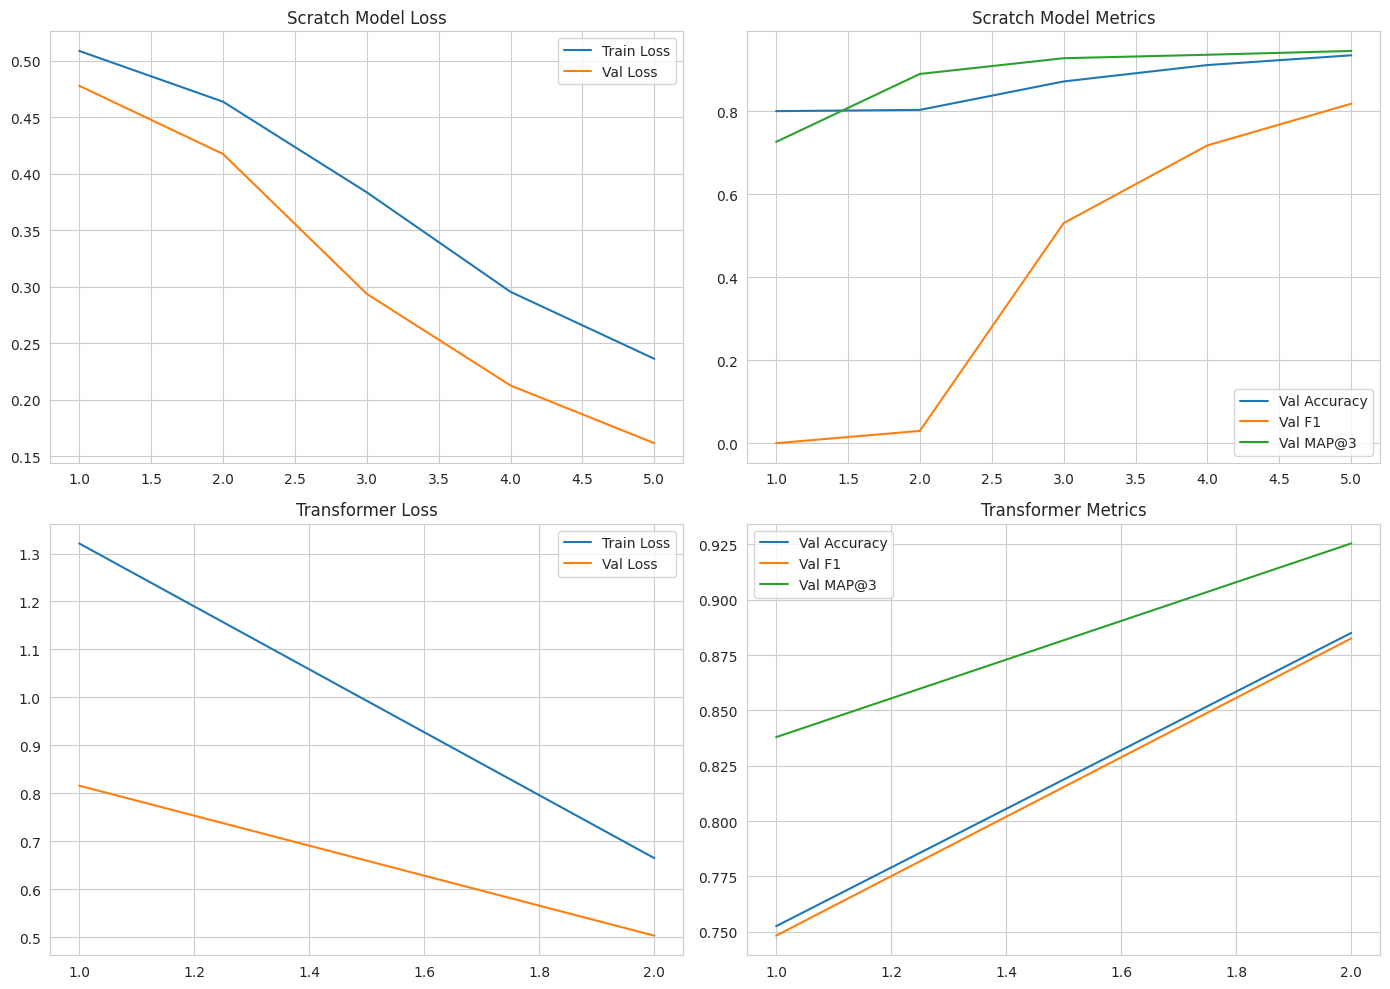

In [32]:
# Plot histories

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

if len(scratch_history) > 0:
    axes[0, 0].plot(scratch_history["epoch"], scratch_history["train_loss"], label="Train Loss")
    axes[0, 0].plot(scratch_history["epoch"], scratch_history["val_loss"], label="Val Loss")
    axes[0, 0].set_title("Scratch Model Loss")
    axes[0, 0].legend()

    axes[0, 1].plot(scratch_history["epoch"], scratch_history["val_accuracy"], label="Val Accuracy")
    axes[0, 1].plot(scratch_history["epoch"], scratch_history["val_f1"], label="Val F1")
    axes[0, 1].plot(scratch_history["epoch"], scratch_history["val_map3"], label="Val MAP@3")
    axes[0, 1].set_title("Scratch Model Metrics")
    axes[0, 1].legend()

if len(mc_history) > 0:
    axes[1, 0].plot(mc_history["epoch"], mc_history["train_loss"], label="Train Loss")
    axes[1, 0].plot(mc_history["epoch"], mc_history["val_loss"], label="Val Loss")
    axes[1, 0].set_title("Transformer Loss")
    axes[1, 0].legend()

    axes[1, 1].plot(mc_history["epoch"], mc_history["val_accuracy"], label="Val Accuracy")
    axes[1, 1].plot(mc_history["epoch"], mc_history["val_f1"], label="Val F1")
    axes[1, 1].plot(mc_history["epoch"], mc_history["val_map3"], label="Val MAP@3")
    axes[1, 1].set_title("Transformer Metrics")
    axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [33]:
# Select Best Model

best_model_name = results.loc[0, "Model"]
print("Best model selected:", best_model_name)


# Submission Helper
def save_submission_from_ranked_lists(ids, ranked_lists, filename="submission.csv"):
    submission = pd.DataFrame({
        "ID": ids,
        "Prediction": [" ".join(x[:3]) for x in ranked_lists]
    })
    submission.to_csv(filename, index=False)
    return submission

Best model selected: Scratch Neural Ranker


In [34]:
# Full retrieval for final training

full_train_df = train_df.copy()
full_test_df = test_df.copy()

full_retrieval_tfidf = TfidfVectorizer(max_features=15000, stop_words="english")
full_train_prompt_vectors = full_retrieval_tfidf.fit_transform(full_train_df["prompt"])
full_test_prompt_vectors = full_retrieval_tfidf.transform(full_test_df["prompt"])

full_train_df["retrieved_context"] = [
    get_retrieved_context(full_train_prompt_vectors[i], full_train_df, full_train_prompt_vectors, top_k=1, exclude_index=i)
    for i in range(full_train_prompt_vectors.shape[0])
]

full_test_df["retrieved_context"] = [
    get_retrieved_context(full_test_prompt_vectors[i], full_train_df, full_train_prompt_vectors, top_k=1, exclude_index=None)
    for i in range(full_test_prompt_vectors.shape[0])
]

# Inferences for Models

In [35]:
# infernce for 
if best_model_name == 'TF-IDF + LightGBM':
    full_train_long = build_long_format(train_df, is_train=True)
    full_test_long = build_long_format(test_df, is_train=False)

    final_tfidf = TfidfVectorizer(
        max_features=TFIDF_MAX_FEATURES,
        ngram_range=(1, 2),
        stop_words='english'
    )

    X_full = final_tfidf.fit_transform(full_train_long['combined_text'])
    X_test = final_tfidf.transform(full_test_long['combined_text'])
    y_full = full_train_long['target'].values

    final_lgbm = lgb.LGBMClassifier(
        objective='binary',
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        random_state=SEED
    )
    final_lgbm.fit(X_full, y_full)

    full_test_long['score'] = final_lgbm.predict_proba(X_test)[:, 1]
    ranked = (
        full_test_long.sort_values(['id', 'score'], ascending=[True, False])
        .groupby('id')['option_label']
        .apply(list)
        .reset_index()
    )

    submission = save_submission_from_ranked_lists(ranked['id'].tolist(), ranked['option_label'].tolist())
    display(submission.head())

In [36]:
# Final inference: scratch model

if best_model_name == "Scratch Neural Ranker":
    full_train_long = build_long_format(full_train_df, is_train=True)
    full_test_long = build_long_format(full_test_df, is_train=False)

    full_counter = Counter()
    for text in full_train_long["combined_text"].tolist():
        full_counter.update(simple_tokenize(text))

    full_vocab = {"<PAD>": 0, "<UNK>": 1}
    for word, freq in full_counter.items():
        if freq >= 2:
            full_vocab[word] = len(full_vocab)

    full_train_dataset = ScratchDataset(full_train_long, full_vocab, MAX_LEN_SCRATCH, is_train=True)
    full_test_dataset = ScratchDataset(full_test_long, full_vocab, MAX_LEN_SCRATCH, is_train=False)

    full_train_loader = DataLoader(full_train_dataset, batch_size=BATCH_SIZE_SCRATCH, shuffle=True)
    full_test_loader = DataLoader(full_test_dataset, batch_size=BATCH_SIZE_SCRATCH, shuffle=False)

    final_scratch_model = SimpleScratchRanker(vocab_size=len(full_vocab)).to(torch.device("cpu"))

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(final_scratch_model.parameters(), lr=SCRATCH_LR)

    for epoch in range(SCRATCH_EPOCHS):
        final_scratch_model.train()
        total_loss = 0.0

        for batch in tqdm(full_train_loader, desc=f"Final Scratch Epoch {epoch+1}"):
            input_ids = batch["input_ids"].to(torch.device("cpu"))
            targets = batch["target"].to(torch.device("cpu"))

            optimizer.zero_grad()
            logits = final_scratch_model(input_ids)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1} Loss: {total_loss/len(full_train_loader):.5f}")

    final_scratch_model.eval()
    records = []

    with torch.no_grad():
        for batch in full_test_loader:
            input_ids = batch["input_ids"].to(torch.device("cpu"))
            probs = torch.sigmoid(final_scratch_model(input_ids)).cpu().numpy()

            for i in range(len(probs)):
                row_id = batch["id"][i].item() if torch.is_tensor(batch["id"][i]) else batch["id"][i]
                records.append({
                    "id": row_id,
                    "option_label": batch["option_label"][i],
                    "score": probs[i]
                })

    pred_df = pd.DataFrame(records)

    ranked = (
        pred_df.sort_values(["id", "score"], ascending=[True, False])
        .groupby("id")["option_label"]
        .apply(list)
        .reset_index()
    )

    submission = save_submission_from_ranked_lists(
        ranked["id"].tolist(),
        ranked["option_label"].tolist()
    )

    display(submission.head())

Final Scratch Epoch 1:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 1 Loss: 0.50389


Final Scratch Epoch 2:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 2 Loss: 0.44764


Final Scratch Epoch 3:   0%|          | 0/157 [00:00<?, ?it/s]

...

Final Scratch Epoch 4:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 4 Loss: 0.24415


Final Scratch Epoch 5:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 5 Loss: 0.20351


,ID,Prediction
0,1,E D B
1,2,B A D
2,3,B E A
3,4,E C A
4,5,C D A


In [37]:
# Final inference: pretrained transformer

if best_model_name == "Multiple Choice Transformer":
    full_train_dataset_mc = MCQDataset(full_train_df, mc_tokenizer, MAX_LEN_TRANSFORMER, is_train=True)
    full_test_dataset_mc = MCQDataset(full_test_df, mc_tokenizer, MAX_LEN_TRANSFORMER, is_train=False)

    full_train_loader_mc = DataLoader(full_train_dataset_mc, batch_size=BATCH_SIZE_TRANSFORMER, shuffle=True)
    full_test_loader_mc = DataLoader(full_test_dataset_mc, batch_size=BATCH_SIZE_TRANSFORMER, shuffle=False)

    final_mc_model = AutoModelForMultipleChoice.from_pretrained(MC_MODEL_NAME).to(device)
    optimizer = AdamW(final_mc_model.parameters(), lr=TRANSFORMER_LR)

    for epoch in range(TRANSFORMER_EPOCHS):
        final_mc_model.train()
        total_loss = 0.0

        for batch in tqdm(full_train_loader_mc, desc=f"Final Transformer Epoch {epoch+1}"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = final_mc_model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1} Loss: {total_loss/len(full_train_loader_mc):.5f}")

    final_mc_model.eval()
    ranked_predictions = []

    with torch.no_grad():
        for batch in full_test_loader_mc:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            outputs = final_mc_model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits.cpu().numpy()

            for i in range(len(logits)):
                ranked_idx = np.argsort(-logits[i])[:3]
                ranked_labels = [id2label[idx] for idx in ranked_idx]
                ranked_predictions.append(ranked_labels)

    ids = full_test_df["id"].tolist()
    submission = save_submission_from_ranked_lists(ids, ranked_predictions)

    display(submission.head())

In [38]:
# Save Submission

submission.to_csv("submission.csv", index=False)
print("submission.csv saved successfully")

submission.csv saved successfully


In [39]:
# Final Check

print("Sample submission columns:", sample_df.columns.tolist())
print("Our submission columns   :", submission.columns.tolist())

submission["num_labels"] = submission["Prediction"].apply(lambda x: len(x.split()))
print(submission["num_labels"].value_counts())

display(submission.head())

Sample submission columns: ['ID', 'Prediction']
Our submission columns   : ['ID', 'Prediction']
num_labels
3    500
Name: count, dtype: int64


,ID,Prediction,num_labels
0,1,E D B,3
1,2,B A D,3
2,3,B E A,3
3,4,E C A,3
4,5,C D A,3
